# TPS Over Time Plot

This notebook loads `tps_series.json`, trims the idle tail after commits stop changing, and draws a clean throughput graph with cumulative committed transactions on a secondary axis.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (14, 8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "axes.facecolor": "#fcfcfd",
    "figure.facecolor": "white",
    "font.size": 12,
})

,view,time,leader_id,executed_slots,elapsed_seconds,tput_measurement,seq,elapsed_from_first_sec
0,1,2026-05-07 23:07:35.597648-04:00,1,250,1.040636,240.237787,250,0.000000
1,1,2026-05-07 23:07:36.602630-04:00,1,500,2.045637,244.422692,500,1.004982
2,1,2026-05-07 23:07:38.109585-04:00,1,750,3.552620,211.111819,750,2.511937
3,1,2026-05-07 23:07:39.137652-04:00,1,1000,4.580707,218.306928,1000,3.540004
4,2,2026-05-07 23:07:41.163296-04:00,2,250,1.414715,176.713986,1250,5.565648


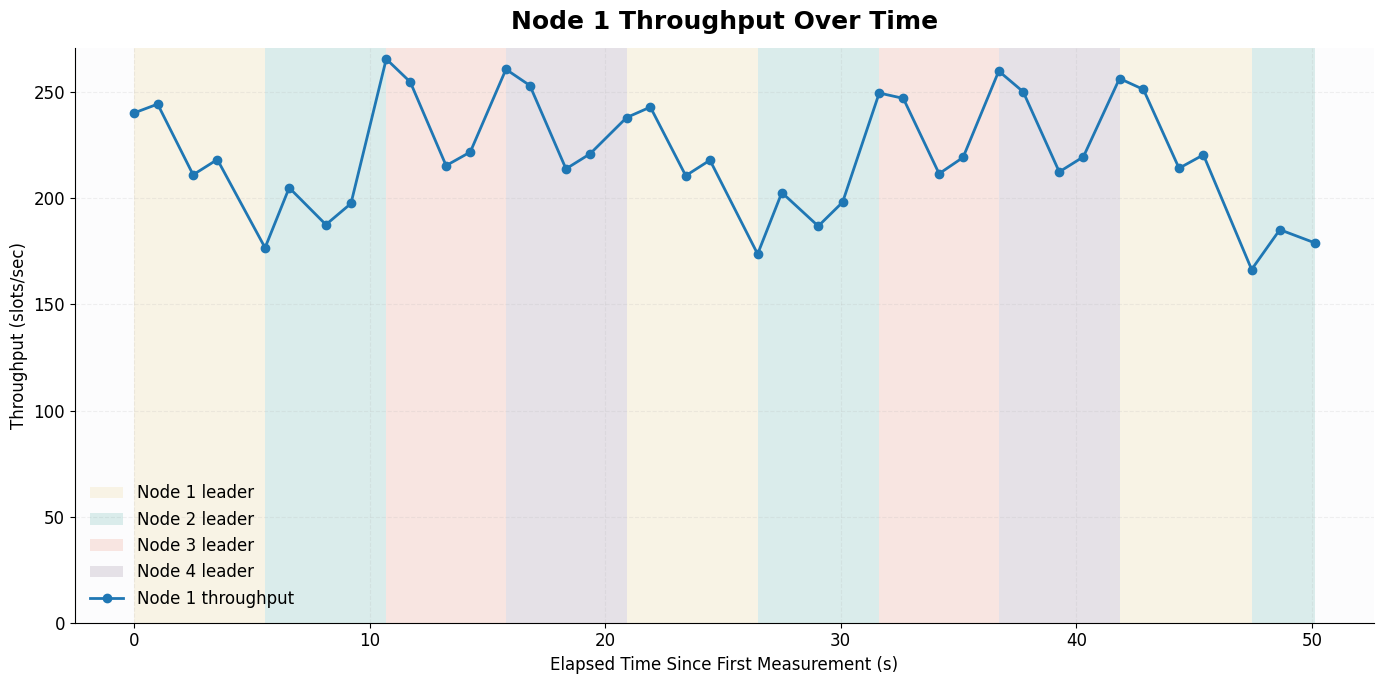

In [21]:
# Change this to pick which node throughput CSV to plot.
node_id = 1

throughput_csv_path = Path("logs") / f"node_{node_id}_throughput.csv"
assert throughput_csv_path.exists(), f"Missing file: {throughput_csv_path.resolve()}"

throughput_df = pd.read_csv(throughput_csv_path)
throughput_df["time"] = pd.to_datetime(throughput_df["time"])
throughput_df = throughput_df.sort_values("time").reset_index(drop=True)
throughput_df["elapsed_from_first_sec"] = (
    throughput_df["time"] - throughput_df["time"].iloc[0]
).dt.total_seconds()

display(throughput_df.head())

fig, ax = plt.subplots(figsize=(14, 7))

leader_colors = {
    1: "#E9C46A",
    2: "#2A9D8F",
    3: "#E76F51",
    4: "#6D597A",
}
leader_change = throughput_df["leader_id"].ne(throughput_df["leader_id"].shift())
segment_id = leader_change.cumsum()
leader_segments = (
    throughput_df.groupby(segment_id)
    .agg(
        leader_id=("leader_id", "first"),
        start_sec=("elapsed_from_first_sec", "first"),
    )
    .reset_index(drop=True)
)
leader_segments["end_sec"] = leader_segments["start_sec"].shift(-1)
leader_segments.loc[leader_segments.index[-1], "end_sec"] = throughput_df[
    "elapsed_from_first_sec"
].iloc[-1]

seen_leaders = set()
for segment in leader_segments.itertuples(index=False):
    leader = int(segment.leader_id)
    label = f"Node {leader} leader" if leader not in seen_leaders else None
    ax.axvspan(
        segment.start_sec,
        segment.end_sec,
        color=leader_colors.get(leader, "#8D99AE"),
        alpha=0.16,
        label=label,
        linewidth=0,
    )
    seen_leaders.add(leader)

ax.plot(
    throughput_df["elapsed_from_first_sec"],
    throughput_df["tput_measurement"],
    marker="o",
    linewidth=2,
    label=f"Node {node_id} throughput",
)

ax.set_title(f"Node {node_id} Throughput Over Time", fontsize=18, weight="bold", pad=14)
ax.set_xlabel("Elapsed Time Since First Measurement (s)")
ax.set_ylabel("Throughput (slots/sec)")
ax.set_ylim(bottom=0)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [15]:
json_path = Path("series.json")
assert json_path.exists(), f"Missing file: {json_path.resolve()}"

with json_path.open() as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df = df.sort_values("elapsed_sec").reset_index(drop=True)
df["window_tps_smooth"] = df["window_tps"].rolling(window=3, min_periods=1).mean()

change_mask = df["committed_total"].ne(df["committed_total"].shift(fill_value=-1))
if change_mask.any():
    last_change_idx = change_mask[change_mask].index[-1]
    plot_df = df.loc[:last_change_idx].copy()
else:
    plot_df = df.copy()

summary = {
    "samples": int(len(df)),
    "plot_samples": int(len(plot_df)),
    "final_committed": int(df["committed_total"].max()),
    "peak_window_tps": float(plot_df["window_tps"].max()),
    "peak_smoothed_tps": float(plot_df["window_tps_smooth"].max()),
    "final_average_tps": float(plot_df["average_tps"].iloc[-1]),
    "elapsed_sec": float(plot_df["elapsed_sec"].iloc[-1]),
}

pd.Series(summary)

samples              2182.000000
plot_samples           10.000000
final_committed       400.000000
peak_window_tps       503.307992
peak_smoothed_tps     325.821920
final_average_tps     200.001646
elapsed_sec             1.999984
dtype: float64

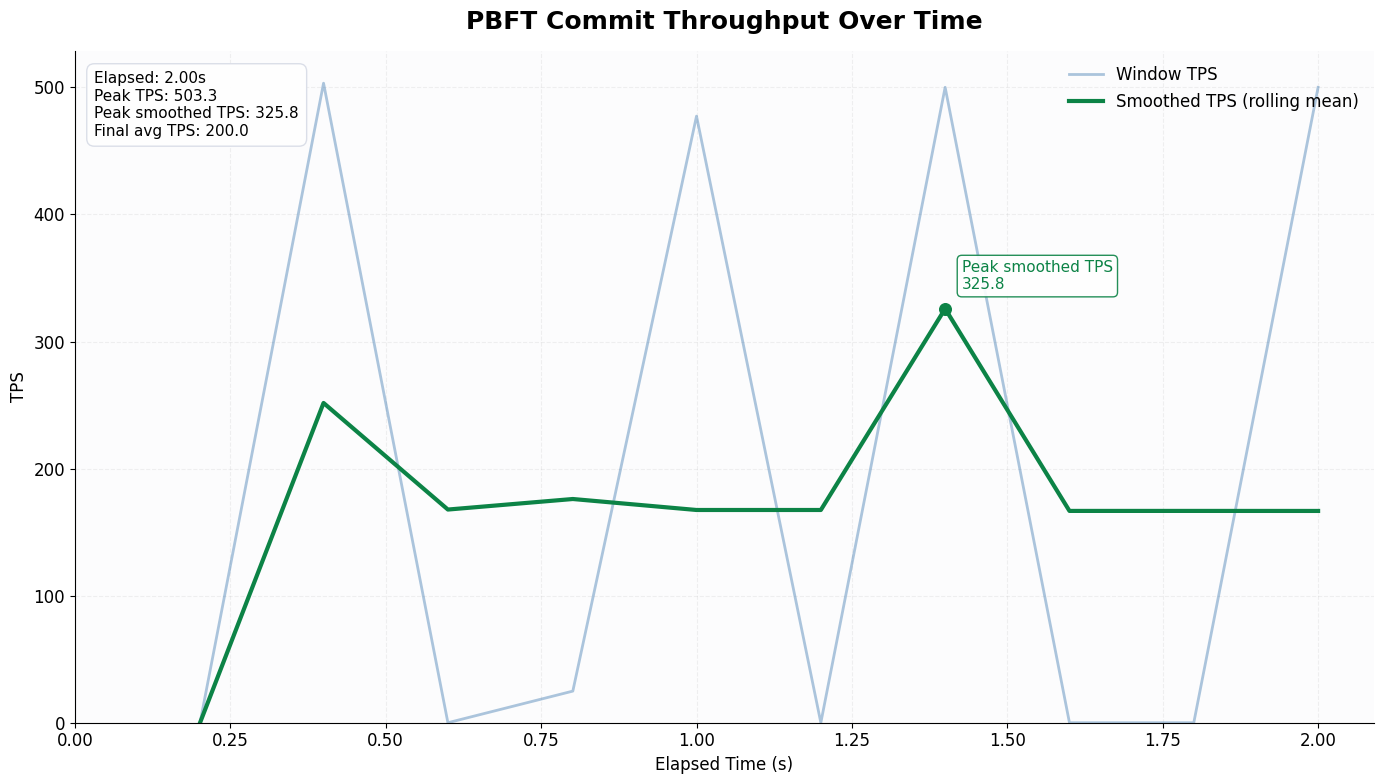

In [16]:
fig, ax1 = plt.subplots()

throughput_color = "#145DA0"
smooth_color = "#0C8346"

ax1.plot(
    plot_df["elapsed_sec"],
    plot_df["window_tps"],
    color=throughput_color,
    linewidth=2.0,
    alpha=0.35,
    label="Window TPS",
)
ax1.plot(
    plot_df["elapsed_sec"],
    plot_df["window_tps_smooth"],
    color=smooth_color,
    linewidth=3.0,
    label="Smoothed TPS (rolling mean)",
)

peak_idx = plot_df["window_tps_smooth"].idxmax()
peak_x = plot_df.loc[peak_idx, "elapsed_sec"]
peak_y = plot_df.loc[peak_idx, "window_tps_smooth"]
ax1.scatter([peak_x], [peak_y], color=smooth_color, s=70, zorder=5)
ax1.annotate(
    f"Peak smoothed TPS\n{peak_y:.1f}",
    xy=(peak_x, peak_y),
    xytext=(12, 14),
    textcoords="offset points",
    fontsize=11,
    color=smooth_color,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=smooth_color, alpha=0.9),
)

ax1.set_title("PBFT Commit Throughput Over Time", fontsize=18, weight="bold", pad=16)
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("TPS")

ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

summary_text = (
    f"Elapsed: {summary['elapsed_sec']:.2f}s\n"
    f"Peak TPS: {summary['peak_window_tps']:.1f}\n"
    f"Peak smoothed TPS: {summary['peak_smoothed_tps']:.1f}\n"
    f"Final avg TPS: {summary['final_average_tps']:.1f}"
)
ax1.text(
    0.015,
    0.97,
    summary_text,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

ax1.legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
output_path = Path("tps_graph_pretty.png")
fig.savefig(output_path, dpi=220, bbox_inches="tight")
output_path.resolve()